# Intersection Analysis

For surveys with traverse lines and control lines, it is common to set a requirement on the differences in value of some particular data channel at the intersection of the traverses and controls. This can be on a height or altitude channel with the purpose of enforcing a relatively smooth flying drape surface. It can be on any geophysical data channel with the purpose of assessing the repeatability of the data as a measure of error.

__pe*ga*susQC__ provides the `checkIntersection` function for intersection analysis. It reports back comparing a maximum allowed value against either individual difference values, or the RMS difference for each traverse line, or the RMS difference divided by $\sqrt{2}$ for each traverse line.

Here we demonstrate its use on the 2012 Kauring airborne gravimetry survey data.

Ensure you have run the `Prepare_ASEGGDF2` notebook first so that the 2012 Kauring data are prepared for review.

___

Import the required modules, and set the path to the geowhizz files.

In [1]:
from pathlib import Path
import pegasusQC as qc

In [2]:
dh = Path(r'./Kauring_grv/GRAV.hdf5')

No field width found in format code  A4


WARNING - no date channel found.

Key channels for linegroup attributes found:
  LINE at 2, FLIGHT at 3.

36 channels to be written to geoWhizz file: 
['EASTING', 'NORTHING', 'LINE', 'FLIGHT', 'FID', 'SECOND',
'UTCSECOND', 'DAYOFYEAR', 'YEAR', 'LATITUDE', 'LONGITUD', 'GPSZ',
'MSLZ', 'ALT', 'ALTTER', 'BAREEARTHTER', 'DEMTER', 'FZ', 'AZ',
'GRVRAW', 'LATCOR', 'EOTCOR', 'FACOR', 'GRVFRA100S', 'INTCOR',
'GRVFRAL100S', 'FTBCOR_267', 'GRVBGL100S_267', 'GRVFAL0600M',
'GRVFAL1000M', 'GRVBGL0600M_267', 'GRVBGL1000M_267',
'FVDBGL0600M_267', 'FVDBGL1000M_267', 'GNDGRV_FA_UPWARD',
'GNDGRV_BG_UPWARD']
Writing to geoWhizz file: Kauring_grv/GRAV.hdf5
Setting Line attributes for Kauring_grv/GRAV.hdf5 to include flight numbers from FLIGHT.
NO ACTION TAKEN ON LINE_TYPE - no plan file provided.
NO ACTION TAKEN ON LINE_TYPE - line_type  not in:
 ['Xcal_nsw', 'Xcal_can', 'SGL_GA', 'SGL_NSW', 'NRG', 'ARK', 'SGL_GDF', 'SGL_Kauring'].
Complete.
Setting ProjectName = Kauring Airborne Gravity for GRAV.hdf5.
Sett

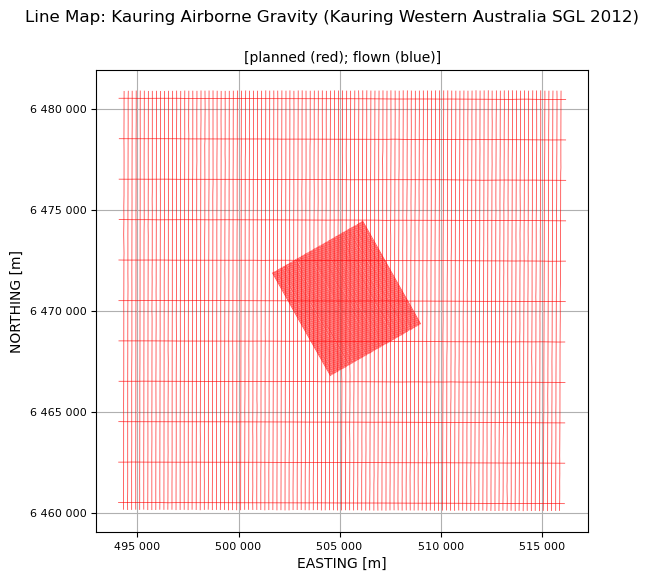

In [7]:
if not dh.exists():
    %run ./Prepare_2012KauringData.ipynb

___

Here is a check for the RMS intersection difference along each traverse line against the Bouguer gravity (filtered at $100\,s$).

In [8]:
qc.checkIntersection(dh, zChannel='GRVBGL100S_267', max_allowed_deltaZ=1.0)

All 224 lines in database indexed as traverse or as control.
213 traverse lines checked,, 5 exceeded the 1.0 mGal allowed RMS difference in GRVBGL100S_267.

  200100:3 [bearing=150.6] intersection GRVBGL100S_267 RMS difference = 1.0 > 1.0 mGal.
  200500:9001 [bearing=-29.6] intersection GRVBGL100S_267 RMS difference = 1.4 > 1.0 mGal.
  200600:3 [bearing=150.5] intersection GRVBGL100S_267 RMS difference = 1.0 > 1.0 mGal.
  200801:15 [bearing=150.5] intersection GRVBGL100S_267 RMS difference = 1.1 > 1.0 mGal.
  208900:4 [bearing=150.7] intersection GRVBGL100S_267 RMS difference = 1.0 > 1.0 mGal.


___

Here is an RMS intersection difference analysis of the survey heights.

In [9]:
qc.checkIntersection(dh, zChannel='GPSZ', max_allowed_deltaZ=10.0)

All 224 lines in database indexed as traverse or as control.
All 213 traverse lines had GPSZ RMS differences less than 10.0 m.


___

In the final example, we analyse the Bouguer gravity against the RMS difference divided by $\sqrt{2}$. With `plot_flag=True`, we get a flight-line map highlighting the failed line(s) in red.

All 224 lines in database indexed as traverse or as control.
213 traverse lines checked,, 1 exceeded the 1.0 mGal allowed RMS/sqrt2 difference in GRVBGL100S_267.

  200500:9001 [bearing=-29.6] intersection GRVBGL100S_267 RMS/sqrt2 difference = 1.0 > 1.0 mGal.


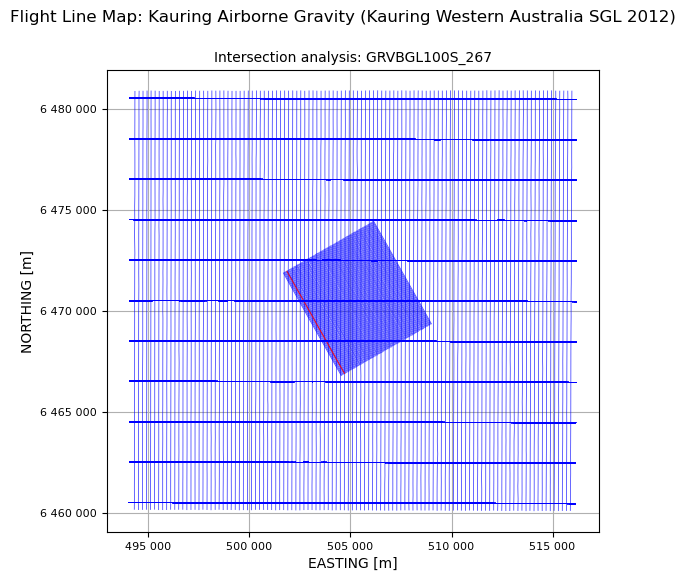

In [10]:
qc.checkIntersection(dh, zChannel='GRVBGL100S_267', max_allowed_deltaZ=1.0, 
                     mode="RMSroot2", plot_flag=True)